In [1]:
# Projet portfolio - E-commerce Olist
# Etape 3b : Prediction du retard de livraison (regression logistique)

# Objectif : predire si une commande sera livree en retard,
# a partir d'informations connues AU MOMENT DE LA COMMANDE


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("olist_dataset_analytique.csv", parse_dates=[
    "order_purchase_timestamp", "order_delivered_customer_date",
    "order_estimated_delivery_date"
])
df_livre = df[df["order_status"] == "delivered"].copy()

In [4]:
# 1. Definition de la cible (target)

df_livre["en_retard"] = (df_livre["retard_estime_jours"] > 0).astype(int)

In [5]:
# 2. Selection des variables explicatives

df_livre["mois_achat"] = df_livre["order_purchase_timestamp"].dt.month
df_livre["jour_semaine_achat"] = df_livre["order_purchase_timestamp"].dt.dayofweek
df_livre["delai_estime_jours"] = (
    df_livre["order_estimated_delivery_date"] - df_livre["order_purchase_timestamp"]
).dt.days

features = [
    "prix_total", "frais_port_total", "nb_produits",
    "payment_installments_max", "mois_achat", "jour_semaine_achat",
    "delai_estime_jours",
]

df_model = df_livre.dropna(subset=features + ["en_retard"]).copy()

X = df_model[features]
y = df_model["en_retard"]

In [6]:
# 3. Split train / test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
# 4. Standardisation (utile pour la regression logistique)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# 5. Entrainement du modele

model = LogisticRegression(class_weight="balanced", random_state=42)
model.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default

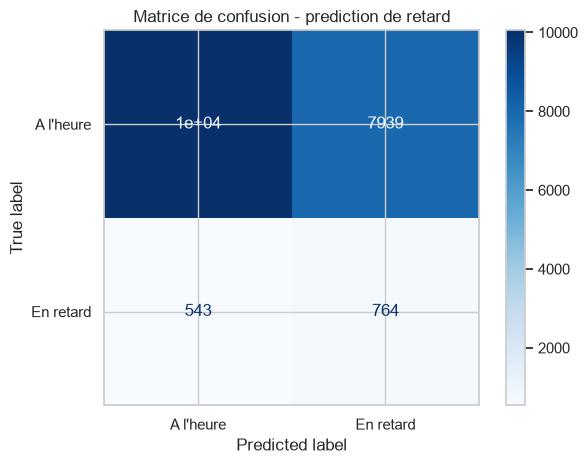

In [9]:
# 6. Evaluation

y_pred = model.predict(X_test_scaled)

classification_report(y_test, y_pred, target_names=["A l'heure", "En retard"], output_dict=False)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["A l'heure", "En retard"])
disp.plot(cmap="Blues")
plt.title("Matrice de confusion - prediction de retard")
plt.tight_layout()
plt.savefig("kpi7_confusion_matrix.png", dpi=150)

In [11]:
classification_report(y_test, y_pred, target_names=["A l'heure", "En retard"], output_dict=False)

"              precision    recall  f1-score   support\n\n   A l'heure       0.95      0.56      0.70     17989\n   En retard       0.09      0.58      0.15      1307\n\n    accuracy                           0.56     19296\n   macro avg       0.52      0.57      0.43     19296\nweighted avg       0.89      0.56      0.67     19296\n"

C:\Users\chokr\AppData\Local\Temp\ipykernel_2760\4192379444.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coefficients, y="variable", x="coefficient", palette="coolwarm")


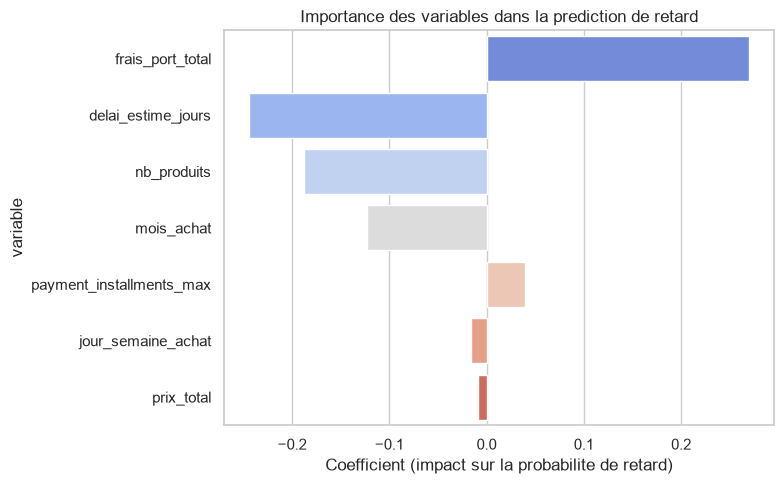

In [10]:
# 7. Importance des variables (coefficients)

coefficients = pd.DataFrame({
    "variable": features,
    "coefficient": model.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=coefficients, y="variable", x="coefficient", palette="coolwarm")
plt.title("Importance des variables dans la prediction de retard")
plt.xlabel("Coefficient (impact sur la probabilite de retard)")
plt.tight_layout()
plt.savefig("kpi8_importance_variables.png", dpi=150)

In [ ]:

# Insight a commenter :
# - quelle variable a le plus fort impact positif sur le risque de retard ?
#   (ex: si delai_estime_jours court -> plus de risque de retard -> recommandation
#    d'etre plus prudent sur les estimations de livraison)